   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00

    ╔═══════════════════════════════════════════════════════════════════════╗
    ║                                                                       ║
    ║          CUSTOM TRAINED JOURNAL ANALYZER                              ║
    ║          Train Your Own Cognitive Distortion Detector                 ║
    ║                                                                       ║
    ╚═══════════════════════════════════════════════════════════════════════╝
    
Generating training data...
Distortion dataset size: 6000
Emotion dataset size: 3000

Dataset Statistics:
  Distortion samples: 6000
  Emotion samples: 3000

TRAINING DISTORTION DETECTION MODEL
Epoch [10/50], Loss: 0.7054, Test Accuracy: 0.1142
Epoch [20/50], Loss: 0.5886, Test Accuracy: 0.9833
Epoch [30/50], Loss: 0.3186, Test Accuracy: 0.9867
Epoch [40/50], Loss: 0.1020, Test Accuracy: 0.9967
Epoch [50/50], Loss: 0.0589, Test Accuracy: 1.00

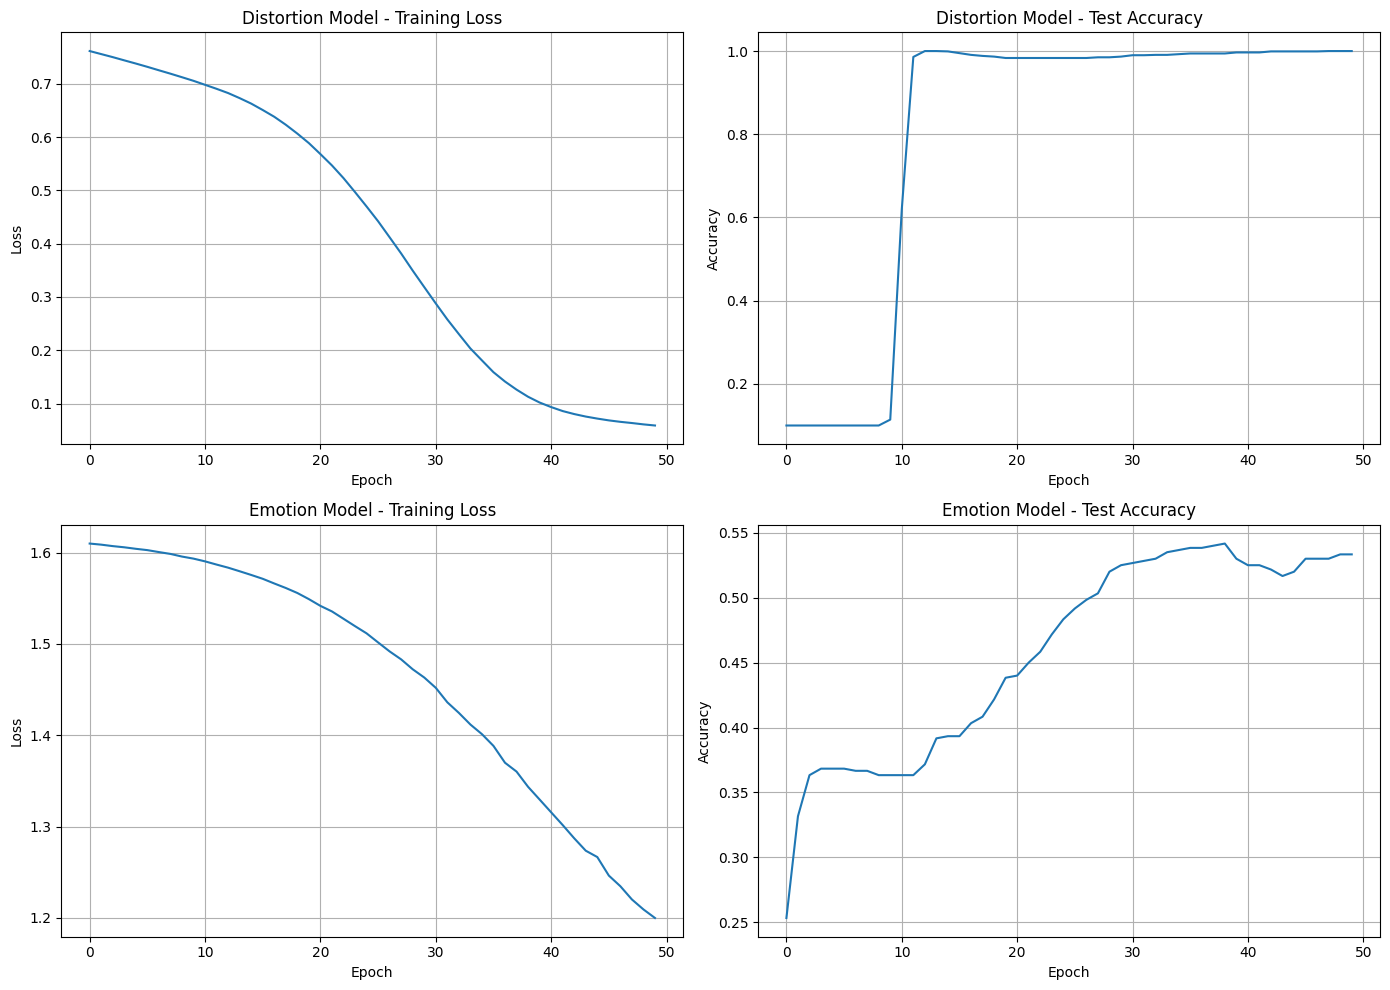


✅ Models saved to journal_analyzer_models.pkl

TESTING ON SAMPLE ENTRIES

TEST ENTRY 1

JOURNAL ANALYSIS REPORT (Custom Models)

📝 Entry: Today was absolutely terrible. I always mess everything up and I'm sure everyone thinks I'm a complete failure....

⚠ DISTORTED
Distortion Probability: 99.60%

🧠 Specific Distortions:
  • All Or Nothing: 3 occurrences
  • Catastrophizing: 1 occurrences

😊 Emotions:
  Primary: Joy (32.7%)

💡 Assessment:
  Level: MODERATE
  Some distortions detected. Try challenging these thoughts.



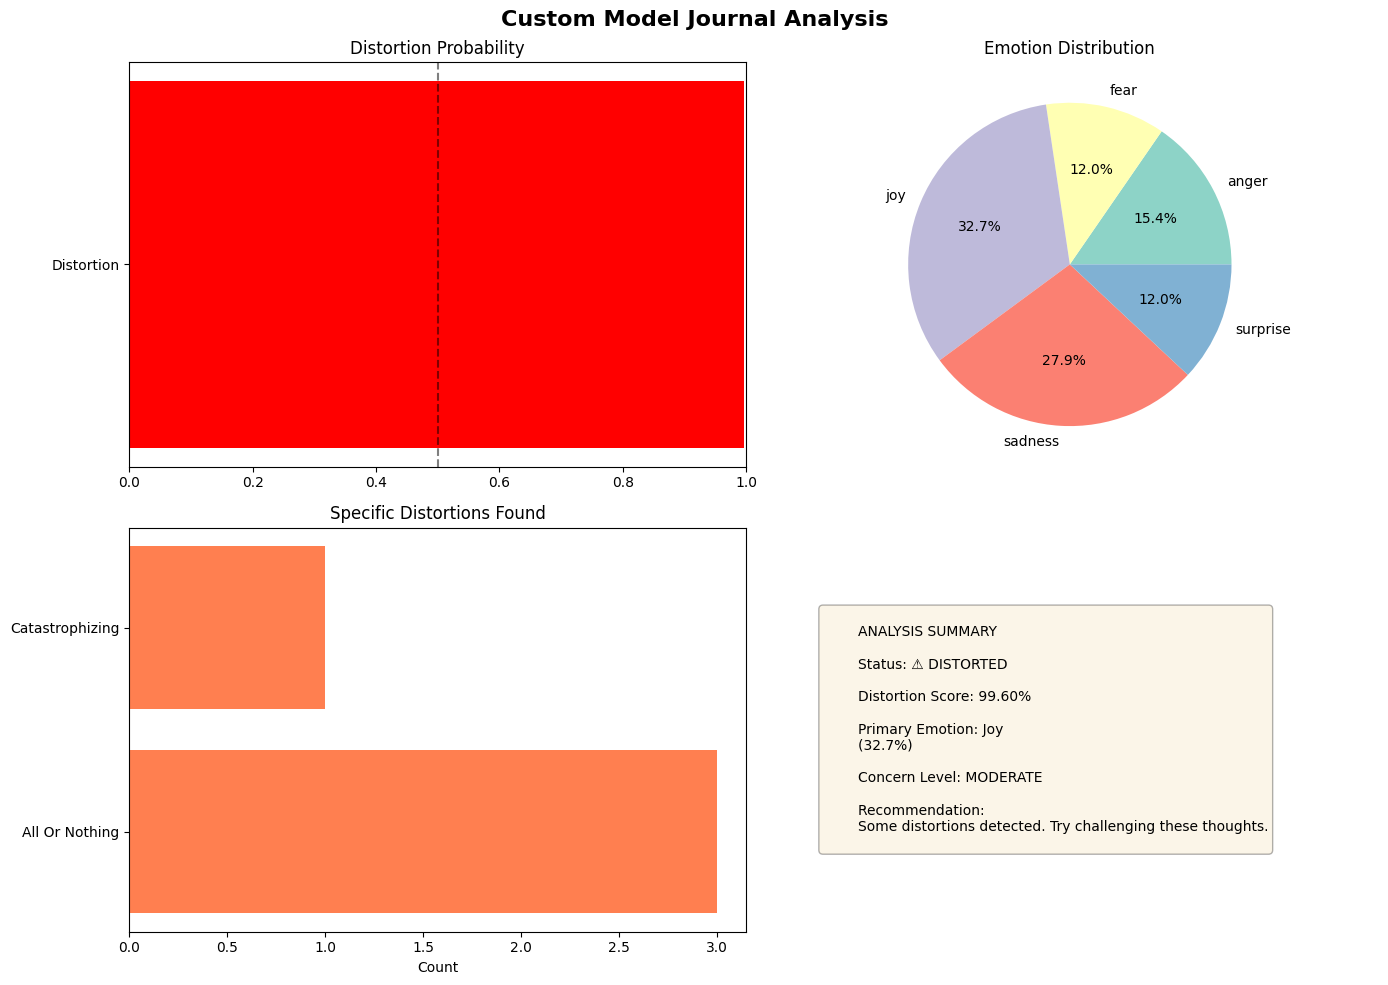


TEST ENTRY 2

JOURNAL ANALYSIS REPORT (Custom Models)

📝 Entry: I had a nice day. Went for a walk and enjoyed the sunshine. Feeling grateful....

⚠ DISTORTED
Distortion Probability: 76.81%

😊 Emotions:
  Primary: Joy (31.1%)

💡 Assessment:
  Level: MODERATE
  Some distortions detected. Try challenging these thoughts.



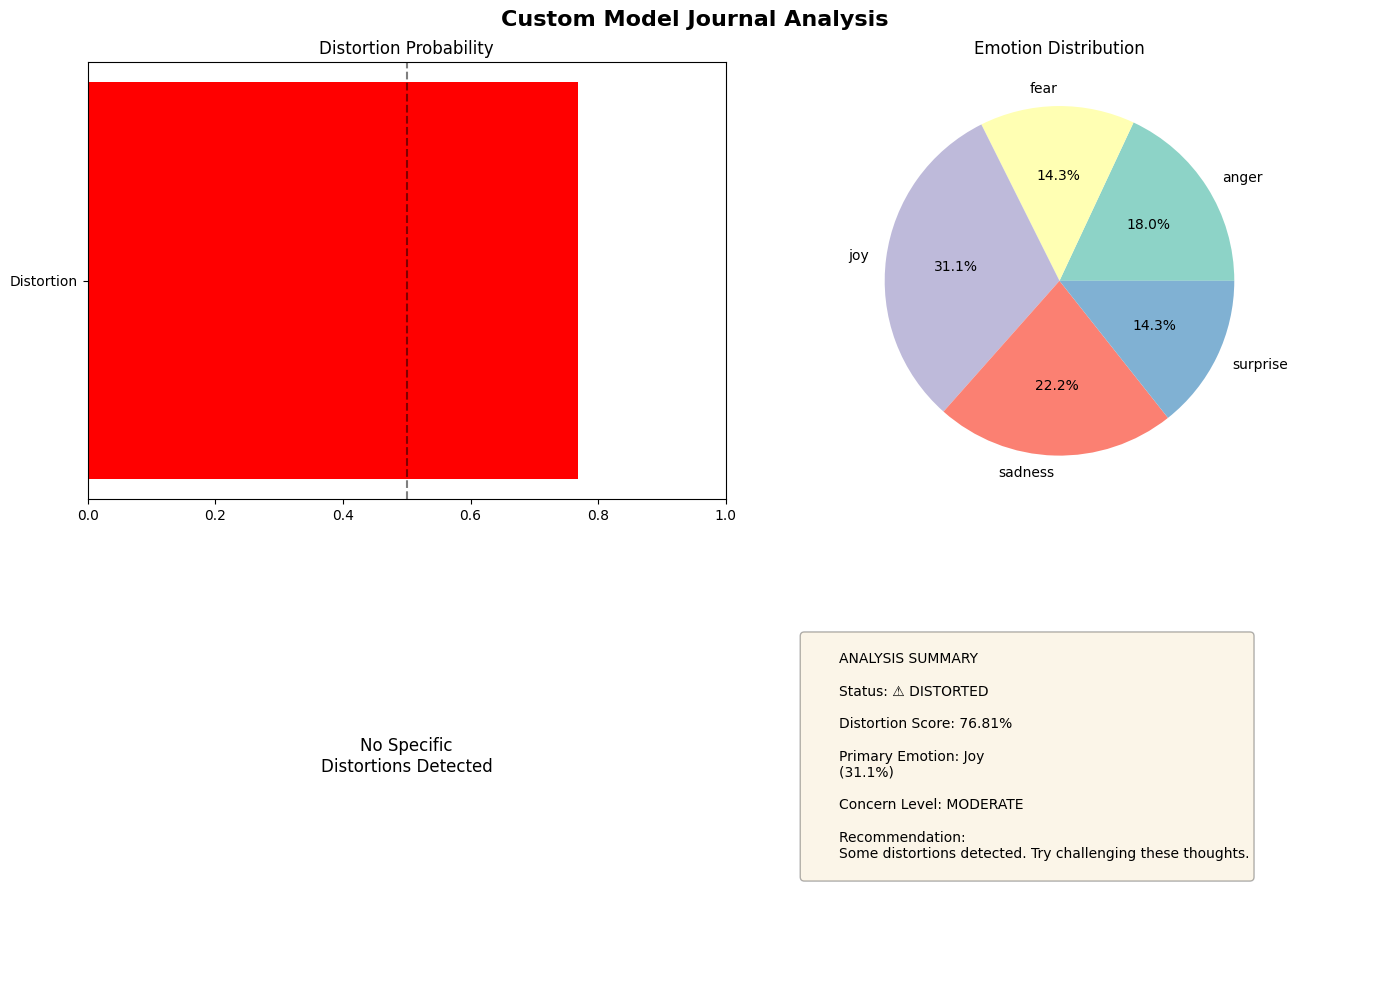


TEST ENTRY 3

JOURNAL ANALYSIS REPORT (Custom Models)

📝 Entry: My friend didn't reply to my text. They must hate me now. This is all my fault. I'm such an idiot....

⚠ DISTORTED
Distortion Probability: 99.88%

🧠 Specific Distortions:
  • Personalization: 1 occurrences
  • Should Statements: 1 occurrences

😊 Emotions:
  Primary: Anger (38.9%)

💡 Assessment:
  Level: HIGH
  Multiple concerning patterns. Consider professional support.



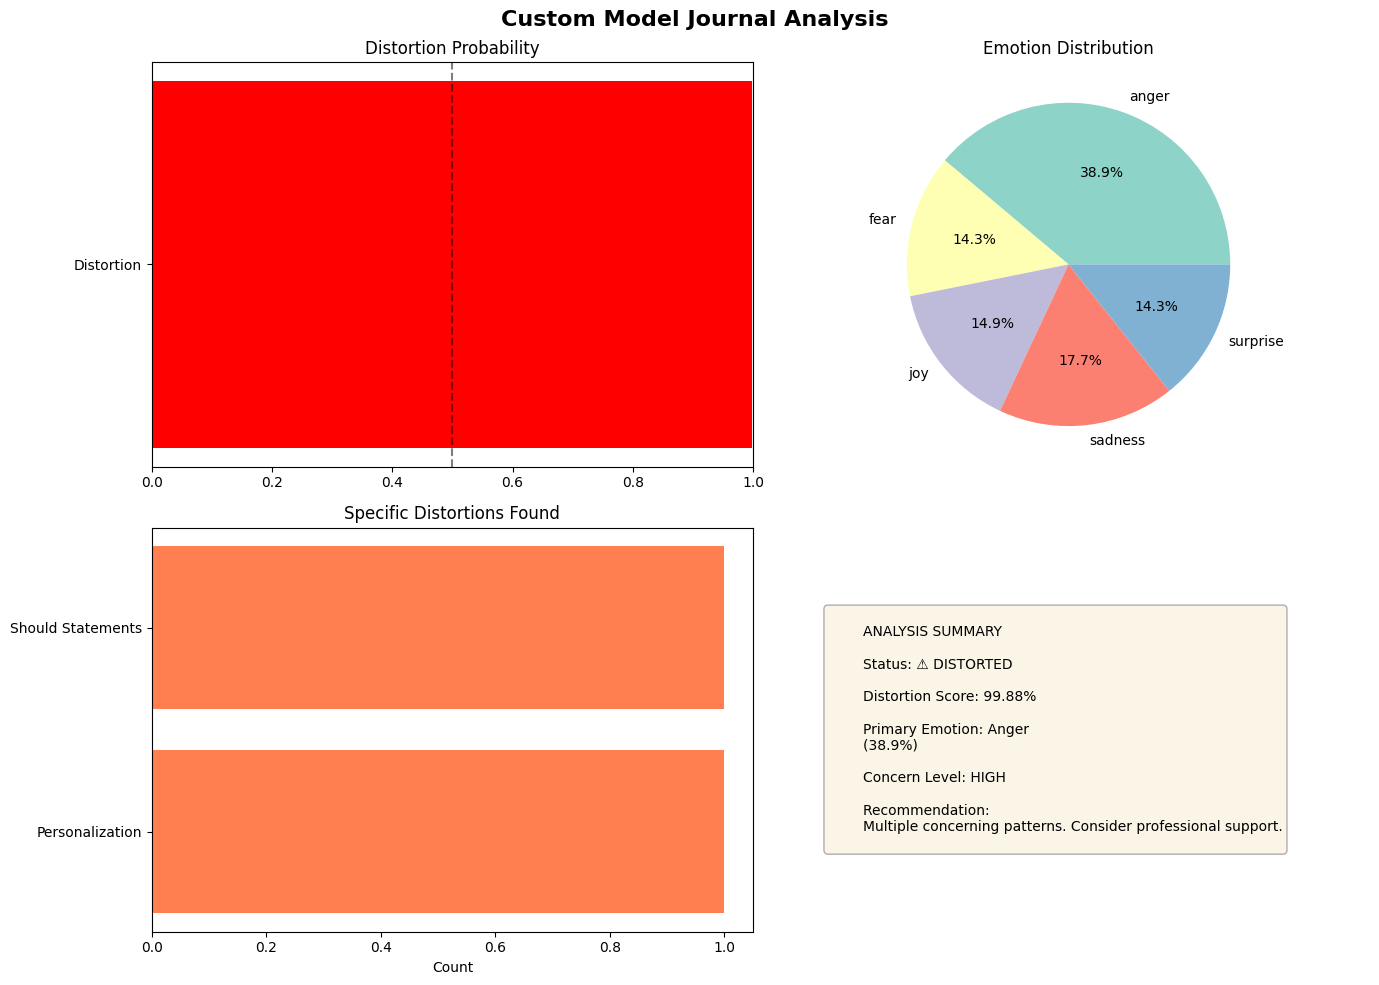


    ✅ Training and Testing Complete!

    📌 Your custom models have been trained and saved.
    💡 These models learn from the patterns in the training data.
    🎯 You can now use them to analyze any journal entry!
    


In [ ]:
!pip install torch scikit-learn pandas numpy matplotlib seaborn textblob vaderSentiment -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# ===========================
# TRAINING DATA GENERATION
# ===========================

class TrainingDataGenerator:
    """Generate synthetic training data for cognitive distortions and emotions"""

    def __init__(self):
        self.distortion_examples = {
            'all_or_nothing': [
                "I always fail at everything I try",
                "Nobody ever likes me",
                "I'm completely worthless",
                "This is totally impossible",
                "Everyone thinks I'm a loser",
                "I never do anything right"
            ],
            'overgeneralization': [
                "This always happens to me",
                "I never get lucky",
                "Every time I try, it fails",
                "Things never work out for me",
                "As usual, I messed up",
                "Typical, another failure"
            ],
            'catastrophizing': [
                "This is the worst thing that could happen",
                "My life is completely ruined",
                "This is a total disaster",
                "I can't handle this at all",
                "Everything is falling apart",
                "This is absolutely terrible"
            ],
            'personalization': [
                "It's all my fault",
                "I'm to blame for this",
                "If only I had done better",
                "I caused all these problems",
                "I should have prevented this",
                "This happened because of me"
            ],
            'should_statements': [
                "I should be doing better",
                "I must succeed at this",
                "I have to be perfect",
                "I shouldn't feel this way",
                "I ought to know better",
                "I need to fix everything"
            ],
            'labeling': [
                "I'm such a failure",
                "I'm a complete idiot",
                "I'm a worthless person",
                "He's a total jerk",
                "She's such a loser",
                "They're all stupid"
            ],
            'mental_filter': [
                "Only the bad things matter",
                "I can't see anything good",
                "Just focusing on what went wrong",
                "The negatives are all that count",
                "I only notice my mistakes",
                "Everything positive doesn't matter"
            ],
            'emotional_reasoning': [
                "I feel like a failure, so I must be one",
                "I feel unloved, therefore nobody loves me",
                "I feel stupid, so I am stupid",
                "It feels wrong, so it must be wrong",
                "I feel anxious, so something bad will happen",
                "I feel guilty, therefore I did something wrong"
            ],
            'jumping_to_conclusions': [
                "They must think I'm incompetent",
                "I know he hates me",
                "She's definitely angry with me",
                "They obviously don't care",
                "I'm sure they're talking about me",
                "He clearly thinks I'm a failure"
            ],
            'healthy': [
                "I had a productive day at work",
                "That was challenging but I learned from it",
                "I feel good about my progress",
                "Today went well overall",
                "I'm grateful for this opportunity",
                "I handled that situation reasonably well"
            ]
        }

        self.emotion_examples = {
            'joy': [
                "I'm so happy about this amazing news!",
                "Today was wonderful, I feel fantastic",
                "I'm excited about the future",
                "This makes me feel so joyful"
            ],
            'sadness': [
                "I feel so down today",
                "This makes me really sad",
                "I'm feeling blue and melancholy",
                "I'm heartbroken about this"
            ],
            'anger': [
                "This makes me so furious",
                "I'm really angry about this situation",
                "I'm frustrated and annoyed",
                "This is infuriating"
            ],
            'fear': [
                "I'm scared this will go wrong",
                "This makes me anxious and worried",
                "I'm terrified of what might happen",
                "I feel afraid and nervous"
            ],
            'surprise': [
                "I can't believe this happened",
                "This is so unexpected",
                "I'm shocked by this news",
                "What a surprise this is"
            ]
        }

    def generate_distortion_dataset(self, samples_per_class=50):
        """Generate training data for distortion detection"""
        data = []

        for distortion_type, examples in self.distortion_examples.items():
            for _ in range(samples_per_class):
                # Add original examples
                text = np.random.choice(examples)
                # Add variations
                if np.random.rand() > 0.5:
                    text = text + " " + np.random.choice(examples)

                label = 1 if distortion_type != 'healthy' else 0
                data.append({
                    'text': text,
                    'label': label,
                    'distortion_type': distortion_type
                })

        return pd.DataFrame(data)

    def generate_emotion_dataset(self, samples_per_emotion=50):
        """Generate training data for emotion detection"""
        data = []

        for emotion, examples in self.emotion_examples.items():
            for _ in range(samples_per_emotion):
                text = np.random.choice(examples)
                # Add variations
                if np.random.rand() > 0.5:
                    text = text + " " + np.random.choice(examples)

                data.append({
                    'text': text,
                    'emotion': emotion
                })

        return pd.DataFrame(data)

    def expand_training_data(self, df, augmentation_factor=3):
        """Expand dataset with augmentations"""
        augmented_data = []

        for _, row in df.iterrows():
            text = row['text']

            # Original
            augmented_data.append(row.to_dict())

            # Augmentations
            for _ in range(augmentation_factor):
                # Add noise words
                noise_words = ['really', 'very', 'so', 'extremely', 'quite', 'somewhat']
                words = text.split()
                if len(words) > 2:
                    insert_pos = np.random.randint(0, len(words))
                    words.insert(insert_pos, np.random.choice(noise_words))
                    augmented_text = ' '.join(words)

                    aug_row = row.to_dict()
                    aug_row['text'] = augmented_text
                    augmented_data.append(aug_row)

        return pd.DataFrame(augmented_data)

# ===========================
# NEURAL NETWORK MODELS
# ===========================

class DistortionClassifier(nn.Module):
    """Neural network for cognitive distortion detection"""

    def __init__(self, input_dim, hidden_dim=128):
        super(DistortionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

class EmotionClassifier(nn.Module):
    """Neural network for emotion classification"""

    def __init__(self, input_dim, num_emotions, hidden_dim=128):
        super(EmotionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, num_emotions)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.relu(self.fc3(x))
        return x

# ===========================
# TRAINING PIPELINE
# ===========================

class ModelTrainer:
    """Train custom models for distortion and emotion detection"""

    def __init__(self):
        self.distortion_model = None
        self.emotion_model = None
        self.vectorizer = None
        self.emotion_encoder = None

    def prepare_data(self):
        """Generate and prepare training data"""
        print("Generating training data...")
        generator = TrainingDataGenerator()

        # Generate distortion data with MORE samples
        distortion_df = generator.generate_distortion_dataset(samples_per_class=100)
        distortion_df = generator.expand_training_data(distortion_df, augmentation_factor=5)
        print(f"Distortion dataset size: {len(distortion_df)}")

        # Generate emotion data with MORE samples
        emotion_df = generator.generate_emotion_dataset(samples_per_emotion=100)
        emotion_df = generator.expand_training_data(emotion_df, augmentation_factor=5)
        print(f"Emotion dataset size: {len(emotion_df)}")

        return distortion_df, emotion_df

    def train_distortion_model(self, df, epochs=50, batch_size=32):
        """Train the distortion detection model"""
        print("\n" + "="*60)
        print("TRAINING DISTORTION DETECTION MODEL")
        print("="*60)

        # Vectorize text
        self.vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 3))
        X = self.vectorizer.fit_transform(df['text']).toarray()
        y = df['label'].values

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

        # Create model
        input_dim = X_train.shape[1]
        self.distortion_model = DistortionClassifier(input_dim, hidden_dim=256)

        # Loss and optimizer
        criterion = nn.BCELoss()
        optimizer = optim.Adam(self.distortion_model.parameters(), lr=0.001)

        # Training loop
        train_losses = []
        test_accuracies = []

        for epoch in range(epochs):
            self.distortion_model.train()

            # Forward pass
            outputs = self.distortion_model(X_train_tensor)
            loss = criterion(outputs, y_train_tensor)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Evaluation
            self.distortion_model.eval()
            with torch.no_grad():
                test_outputs = self.distortion_model(X_test_tensor)
                test_predictions = (test_outputs > 0.5).float()
                test_accuracy = (test_predictions == y_test_tensor).float().mean().item()

            train_losses.append(loss.item())
            test_accuracies.append(test_accuracy)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}")

        # Final evaluation
        self.distortion_model.eval()
        with torch.no_grad():
            test_outputs = self.distortion_model(X_test_tensor)
            test_predictions = (test_outputs > 0.5).float()
            test_accuracy = (test_predictions == y_test_tensor).float().mean().item()

        print(f"\n✅ Final Test Accuracy: {test_accuracy:.4f}")

        return train_losses, test_accuracies

    def train_emotion_model(self, df, epochs=50, batch_size=32):
        """Train the emotion classification model"""
        print("\n" + "="*60)
        print("TRAINING EMOTION CLASSIFICATION MODEL")
        print("="*60)

        # Encode emotions
        from sklearn.preprocessing import LabelEncoder
        self.emotion_encoder = LabelEncoder()
        y = self.emotion_encoder.fit_transform(df['emotion'])

        # Vectorize text
        if self.vectorizer is None:
            self.vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 3))
            X = self.vectorizer.fit_transform(df['text']).toarray()
        else:
            X = self.vectorizer.transform(df['text']).toarray()

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.LongTensor(y_train)
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.LongTensor(y_test)

        # Create model
        input_dim = X_train.shape[1]
        num_emotions = len(self.emotion_encoder.classes_)
        self.emotion_model = EmotionClassifier(input_dim, num_emotions, hidden_dim=256)

        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.emotion_model.parameters(), lr=0.001)

        # Training loop
        train_losses = []
        test_accuracies = []

        for epoch in range(epochs):
            self.emotion_model.train()

            # Forward pass
            outputs = self.emotion_model(X_train_tensor)
            loss = criterion(outputs, y_train_tensor)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Evaluation
            self.emotion_model.eval()
            with torch.no_grad():
                test_outputs = self.emotion_model(X_test_tensor)
                _, test_predictions = torch.max(test_outputs, 1)
                test_accuracy = (test_predictions == y_test_tensor).float().mean().item()

            train_losses.append(loss.item())
            test_accuracies.append(test_accuracy)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}")

        print(f"\n✅ Final Test Accuracy: {test_accuracy:.4f}")

        return train_losses, test_accuracies

    def plot_training_history(self, distortion_losses, distortion_acc, emotion_losses, emotion_acc):
        """Plot training history"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Distortion loss
        axes[0, 0].plot(distortion_losses)
        axes[0, 0].set_title('Distortion Model - Training Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].grid(True)

        # Distortion accuracy
        axes[0, 1].plot(distortion_acc)
        axes[0, 1].set_title('Distortion Model - Test Accuracy')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].grid(True)

        # Emotion loss
        axes[1, 0].plot(emotion_losses)
        axes[1, 0].set_title('Emotion Model - Training Loss')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].grid(True)

        # Emotion accuracy
        axes[1, 1].plot(emotion_acc)
        axes[1, 1].set_title('Emotion Model - Test Accuracy')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Accuracy')
        axes[1, 1].grid(True)

        plt.tight_layout()
        plt.show()

    def save_models(self, filepath='journal_analyzer_models.pkl'):
        """Save trained models"""
        models = {
            'distortion_model': self.distortion_model.state_dict(),
            'emotion_model': self.emotion_model.state_dict(),
            'vectorizer': self.vectorizer,
            'emotion_encoder': self.emotion_encoder
        }
        with open(filepath, 'wb') as f:
            pickle.dump(models, f)
        print(f"\n✅ Models saved to {filepath}")

# ===========================
# CUSTOM JOURNAL ANALYZER
# ===========================

class CustomJournalAnalyzer:
    """Journal analyzer using custom trained models"""

    def __init__(self, trainer):
        self.distortion_model = trainer.distortion_model
        self.emotion_model = trainer.emotion_model
        self.vectorizer = trainer.vectorizer
        self.emotion_encoder = trainer.emotion_encoder

        self.distortion_patterns = {
            'all_or_nothing': [
                r'\b(always|never|every|no one|everyone|everything|nothing|completely|totally)\b'
            ],
            'overgeneralization': [
                r'\b(always happens|never works|typical|as usual|every time)\b'
            ],
            'catastrophizing': [
                r'\b(disaster|catastrophe|terrible|horrible|awful|worst|ruined|destroyed)\b'
            ],
            'personalization': [
                r'\b(my fault|I\'m to blame|because of me|I caused)\b'
            ],
            'should_statements': [
                r'\b(should|shouldn\'t|must|mustn\'t|ought to|have to)\b'
            ],
            'labeling': [
                r'\b(I\'m a|I am a)\b.*\b(loser|failure|idiot|stupid)\b'
            ]
        }

    def detect_distortions_pattern(self, text):
        """Detect specific distortion patterns"""
        text_lower = text.lower()
        detected = {}

        for distortion, patterns in self.distortion_patterns.items():
            matches = []
            for pattern in patterns:
                found = re.findall(pattern, text_lower)
                if found:
                    matches.extend(found)

            if matches:
                detected[distortion] = {
                    'found': True,
                    'count': len(matches),
                    'examples': matches[:3]
                }

        return detected

    def analyze_entry(self, text):
        """Analyze a journal entry"""
        # Vectorize text
        X = self.vectorizer.transform([text]).toarray()
        X_tensor = torch.FloatTensor(X)

        # Predict distortion
        self.distortion_model.eval()
        with torch.no_grad():
            distortion_prob = self.distortion_model(X_tensor).item()

        is_distorted = distortion_prob > 0.5

        # Predict emotion
        self.emotion_model.eval()
        with torch.no_grad():
            emotion_outputs = self.emotion_model(X_tensor)
            emotion_probs = torch.softmax(emotion_outputs, dim=1).squeeze().numpy()
            emotion_idx = torch.argmax(emotion_outputs, dim=1).item()

        primary_emotion = self.emotion_encoder.classes_[emotion_idx]

        # Get emotion distribution
        emotion_scores = {
            emotion: float(prob)
            for emotion, prob in zip(self.emotion_encoder.classes_, emotion_probs)
        }

        # Detect specific distortion patterns
        distortions = self.detect_distortions_pattern(text)

        # Assessment
        health_assessment = self._assess_mental_health(
            distortion_prob, primary_emotion, distortions
        )

        return {
            'text': text,
            'is_distorted': is_distorted,
            'distortion_score': distortion_prob,
            'distortions_detected': distortions,
            'emotion_analysis': {
                'emotions': emotion_scores,
                'primary_emotion': primary_emotion,
                'primary_emotion_score': emotion_scores[primary_emotion]
            },
            'health_assessment': health_assessment
        }

    def _assess_mental_health(self, distortion_score, primary_emotion, distortions):
        """Assess mental health based on analysis"""
        concerns = []

        if distortion_score > 0.7:
            concerns.append("High level of cognitive distortions detected")
        elif distortion_score > 0.5:
            concerns.append("Moderate cognitive distortions present")

        if primary_emotion in ['sadness', 'fear', 'anger'] and distortion_score > 0.6:
            concerns.append(f"Strong {primary_emotion} with distorted thinking")

        if len(distortions) >= 3:
            concerns.append("Multiple distortion patterns identified")

        if concerns:
            level = 'high' if len(concerns) >= 2 else 'moderate'
        else:
            level = 'low'

        recommendations = {
            'low': "Your thinking patterns appear healthy. Keep journaling!",
            'moderate': "Some distortions detected. Try challenging these thoughts.",
            'high': "Multiple concerning patterns. Consider professional support."
        }

        return {
            'concern_level': level,
            'concerns': concerns,
            'recommendation': recommendations[level]
        }

    def visualize_analysis(self, analysis):
        """Visualize analysis results"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Custom Model Journal Analysis', fontsize=16, fontweight='bold')

        # 1. Distortion Score
        ax1 = axes[0, 0]
        score = analysis['distortion_score']
        colors = ['green' if score < 0.3 else 'orange' if score < 0.7 else 'red']
        ax1.barh(['Distortion'], [score], color=colors)
        ax1.set_xlim([0, 1])
        ax1.set_title('Distortion Probability')
        ax1.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

        # 2. Emotion Distribution
        ax2 = axes[0, 1]
        emotions = analysis['emotion_analysis']['emotions']
        em_names = list(emotions.keys())
        em_scores = list(emotions.values())
        colors_em = plt.cm.Set3(range(len(em_names)))
        ax2.pie(em_scores, labels=em_names, autopct='%1.1f%%', colors=colors_em)
        ax2.set_title('Emotion Distribution')

        # 3. Specific Distortions
        ax3 = axes[1, 0]
        if analysis['distortions_detected']:
            dist_names = [d.replace('_', ' ').title()
                         for d in analysis['distortions_detected'].keys()]
            dist_counts = [analysis['distortions_detected'][d]['count']
                          for d in analysis['distortions_detected'].keys()]
            ax3.barh(dist_names, dist_counts, color='coral')
            ax3.set_xlabel('Count')
            ax3.set_title('Specific Distortions Found')
        else:
            ax3.text(0.5, 0.5, 'No Specific\nDistortions Detected',
                    ha='center', va='center', fontsize=12)
            ax3.axis('off')

        # 4. Summary
        ax4 = axes[1, 1]
        ax4.axis('off')

        summary = f"""
        ANALYSIS SUMMARY

        Status: {'⚠ DISTORTED' if analysis['is_distorted'] else '✓ HEALTHY'}

        Distortion Score: {analysis['distortion_score']:.2%}

        Primary Emotion: {analysis['emotion_analysis']['primary_emotion'].title()}
        ({analysis['emotion_analysis']['primary_emotion_score']:.1%})

        Concern Level: {analysis['health_assessment']['concern_level'].upper()}

        Recommendation:
        {analysis['health_assessment']['recommendation']}
        """

        ax4.text(0.1, 0.5, summary, fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

        plt.tight_layout()
        plt.show()

    def print_report(self, analysis):
        """Print detailed report"""
        print("\n" + "="*80)
        print("JOURNAL ANALYSIS REPORT (Custom Models)")
        print("="*80)

        print(f"\n📝 Entry: {analysis['text'][:150]}...")
        print(f"\n{'⚠ DISTORTED' if analysis['is_distorted'] else '✓ HEALTHY'}")
        print(f"Distortion Probability: {analysis['distortion_score']:.2%}")

        if analysis['distortions_detected']:
            print(f"\n🧠 Specific Distortions:")
            for dist, details in analysis['distortions_detected'].items():
                print(f"  • {dist.replace('_', ' ').title()}: {details['count']} occurrences")

        print(f"\n😊 Emotions:")
        print(f"  Primary: {analysis['emotion_analysis']['primary_emotion'].title()} "
              f"({analysis['emotion_analysis']['primary_emotion_score']:.1%})")

        print(f"\n💡 Assessment:")
        print(f"  Level: {analysis['health_assessment']['concern_level'].upper()}")
        print(f"  {analysis['health_assessment']['recommendation']}")
        print("\n" + "="*80)

# ===========================
# MAIN EXECUTION
# ===========================

def main():
    print("""
    ╔═══════════════════════════════════════════════════════════════════════╗
    ║                                                                       ║
    ║          CUSTOM TRAINED JOURNAL ANALYZER                              ║
    ║          Train Your Own Cognitive Distortion Detector                 ║
    ║                                                                       ║
    ╚═══════════════════════════════════════════════════════════════════════╝
    """)

    # Train models
    trainer = ModelTrainer()
    distortion_df, emotion_df = trainer.prepare_data()

    print(f"\nDataset Statistics:")
    print(f"  Distortion samples: {len(distortion_df)}")
    print(f"  Emotion samples: {len(emotion_df)}")

    # Train distortion model
    d_losses, d_acc = trainer.train_distortion_model(distortion_df, epochs=50)

    # Train emotion model
    e_losses, e_acc = trainer.train_emotion_model(emotion_df, epochs=50)

    # Plot training history
    trainer.plot_training_history(d_losses, d_acc, e_losses, e_acc)

    # Save models
    trainer.save_models()

    # Test on sample entries
    print("\n" + "="*80)
    print("TESTING ON SAMPLE ENTRIES")
    print("="*80)

    analyzer = CustomJournalAnalyzer(trainer)

    test_entries = [
        "Today was absolutely terrible. I always mess everything up and I'm sure everyone thinks I'm a complete failure.",
        "I had a nice day. Went for a walk and enjoyed the sunshine. Feeling grateful.",
        "My friend didn't reply to my text. They must hate me now. This is all my fault. I'm such an idiot."
    ]

    for i, entry in enumerate(test_entries, 1):
        print(f"\n{'='*80}")
        print(f"TEST ENTRY {i}")
        print(f"{'='*80}")

        analysis = analyzer.analyze_entry(entry)
        analyzer.print_report(analysis)
        analyzer.visualize_analysis(analysis)

    print("""
    ✅ Training and Testing Complete!

    📌 Your custom models have been trained and saved.
    💡 These models learn from the patterns in the training data.
    🎯 You can now use them to analyze any journal entry!
    """)

if __name__ == "__main__":
    main()

In [ ]:
import pickle
import torch
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import re # Added to ensure CustomJournalAnalyzer works if copied here

# ==================================================================
# IMPORTANT: You need to have the class definitions from the original
# notebook (DistortionClassifier, EmotionClassifier, CustomJournalAnalyzer)
# copied into your Flask application's codebase for this to work.
# ==================================================================

# Re-define or import your model classes and analyzer class (from original notebook)
# For demonstration, I'll include minimal versions of required classes.
# In your Flask app, you'd import them from where you define them.

class DistortionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super(DistortionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

class EmotionClassifier(nn.Module):
    def __init__(self, input_dim, num_emotions, hidden_dim=128):
        super(EmotionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, num_emotions)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.relu(self.fc3(x))
        return x

# --- Loading the models and components ---

filepath = 'journal_analyzer_models.pkl'

try:
    with open(filepath, 'rb') as f:
        loaded_data = pickle.load(f)

    # Load vectorizer and emotion encoder directly
    loaded_vectorizer = loaded_data['vectorizer']
    loaded_emotion_encoder = loaded_data['emotion_encoder']

    # Reconstruct Distortion Model
    # You need the input_dim from the vectorizer AFTER it's loaded
    input_dim = loaded_vectorizer.transform(['test']).shape[1]
    loaded_distortion_model = DistortionClassifier(input_dim, hidden_dim=256) # Corrected hidden_dim
    loaded_distortion_model.load_state_dict(loaded_data['distortion_model'])
    loaded_distortion_model.eval() # Set to evaluation mode

    # Reconstruct Emotion Model
    num_emotions = len(loaded_emotion_encoder.classes_)
    loaded_emotion_model = EmotionClassifier(input_dim, num_emotions, hidden_dim=256) # Corrected hidden_dim
    loaded_emotion_model.load_state_dict(loaded_data['emotion_model'])
    loaded_emotion_model.eval() # Set to evaluation mode

    print("✅ Models and components loaded successfully!")
    print(f"Vectorizer vocabulary size: {len(loaded_vectorizer.vocabulary_)}")
    print(f"Emotion classes: {loaded_emotion_encoder.classes_}")

    # Now you can use loaded_distortion_model, loaded_emotion_model,
    # loaded_vectorizer, and loaded_emotion_encoder for predictions.

except FileNotFoundError:
    print(f"Error: The file '{filepath}' was not found. Please ensure it's in the correct directory.")
except Exception as e:
    print(f"An error occurred while loading the models: {e}")


✅ Models and components loaded successfully!
Vectorizer vocabulary size: 500
Emotion classes: ['anger' 'fear' 'joy' 'sadness' 'surprise']


Once loaded, you can define a function in your Flask app that takes text input, preprocesses it using the `loaded_vectorizer`, passes it through the `loaded_distortion_model` and `loaded_emotion_model`, and then decodes the emotion using `loaded_emotion_encoder`.

Here's an example of how you might use the loaded models to analyze a new entry:

In [ ]:
import re
import numpy as np

# Assuming the CustomJournalAnalyzer class is also available in your Flask app
# For simplicity, let's create a minimal version here for demonstration.
class CustomJournalAnalyzer:
    def __init__(self, distortion_model, emotion_model, vectorizer, emotion_encoder):
        self.distortion_model = distortion_model
        self.emotion_model = emotion_model
        self.vectorizer = vectorizer
        self.emotion_encoder = emotion_encoder

        self.distortion_patterns = {
            'all_or_nothing': [r'\b(always|never|every|no one|everyone|everything|nothing|completely|totally)\b'],
            'overgeneralization': [r'\b(always happens|never works|typical|as usual|every time)\b'],
            'catastrophizing': [r'\b(disaster|catastrophe|terrible|horrible|awful|worst|ruined|destroyed)\b'],
            'personalization': [r'\b(my fault|I\'m to blame|because of me|I caused)\b'],
            'should_statements': [r'\b(should|shouldn\'t|must|mustn\'t|ought to|have to)\b'],
            'labeling': [r'\b(I\'m a|I am a)\b.*\b(loser|failure|idiot|stupid)\b']
        }

    def detect_distortions_pattern(self, text):
        text_lower = text.lower()
        detected = {}
        for distortion, patterns in self.distortion_patterns.items():
            matches = []
            for pattern in patterns:
                found = re.findall(pattern, text_lower)
                if found:
                    matches.extend(found)
            if matches:
                detected[distortion] = {'found': True, 'count': len(matches), 'examples': matches[:3]}
        return detected

    def _assess_mental_health(self, distortion_score, primary_emotion, distortions):
        concerns = []
        if distortion_score > 0.7: concerns.append("High level of cognitive distortions detected")
        elif distortion_score > 0.5: concerns.append("Moderate cognitive distortions present")
        if primary_emotion in ['sadness', 'fear', 'anger'] and distortion_score > 0.6: concerns.append(f"Strong {primary_emotion} with distorted thinking")
        if len(distortions) >= 3: concerns.append("Multiple distortion patterns identified")

        if concerns: level = 'high' if len(concerns) >= 2 else 'moderate'
        else: level = 'low'

        recommendations = {
            'low': "Your thinking patterns appear healthy. Keep journaling!",
            'moderate': "Some distortions detected. Try challenging these thoughts.",
            'high': "Multiple concerning patterns. Consider professional support."
        }
        return {'concern_level': level, 'concerns': concerns, 'recommendation': recommendations[level]}

    def analyze_entry(self, text):
        X = self.vectorizer.transform([text]).toarray()
        X_tensor = torch.FloatTensor(X)

        with torch.no_grad():
            distortion_prob = self.distortion_model(X_tensor).item()
        is_distorted = distortion_prob > 0.5

        with torch.no_grad():
            emotion_outputs = self.emotion_model(X_tensor)
            emotion_probs = torch.softmax(emotion_outputs, dim=1).squeeze().numpy()
            emotion_idx = torch.argmax(emotion_outputs, dim=1).item()
        primary_emotion = self.emotion_encoder.classes_[emotion_idx]

        emotion_scores = {emotion: float(prob) for emotion, prob in zip(self.emotion_encoder.classes_, emotion_probs)}

        distortions = self.detect_distortions_pattern(text)
        health_assessment = self._assess_mental_health(distortion_prob, primary_emotion, distortions)

        return {
            'text': text,
            'is_distorted': is_distorted,
            'distortion_score': distortion_prob,
            'distortions_detected': distortions,
            'emotion_analysis': {
                'emotions': emotion_scores,
                'primary_emotion': primary_emotion,
                'primary_emotion_score': emotion_scores[primary_emotion]
            },
            'health_assessment': health_assessment
        }


# --- Example Usage with the loaded models ---
if 'loaded_distortion_model' in locals(): # Check if models were loaded successfully
    analyzer_instance = CustomJournalAnalyzer(
        loaded_distortion_model,
        loaded_emotion_model,
        loaded_vectorizer,
        loaded_emotion_encoder
    )

    test_entry_flask = "I messed up on that presentation. I always do this, I'm such a failure. Everyone is going to think I'm incompetent."
    analysis_result = analyzer_instance.analyze_entry(test_entry_flask)

    print("\n--- Analysis for a new entry ---")
    print(f"Entry: {analysis_result['text']}")
    print(f"Is Distorted: {analysis_result['is_distorted']}")
    print(f"Distortion Score: {analysis_result['distortion_score']:.2%}")
    print(f"Primary Emotion: {analysis_result['emotion_analysis']['primary_emotion']} ({analysis_result['emotion_analysis']['primary_emotion_score']:.2%})")
    print(f"Detected Distortions: {analysis_result['distortions_detected']}")
    print(f"Concern Level: {analysis_result['health_assessment']['concern_level']}")
    print(f"Recommendation: {analysis_result['health_assessment']['recommendation']}")
else:
    print("Models could not be loaded. Please check the previous output for errors.")



--- Analysis for a new entry ---
Entry: I messed up on that presentation. I always do this, I'm such a failure. Everyone is going to think I'm incompetent.
Is Distorted: True
Distortion Score: 99.92%
Primary Emotion: anger (29.77%)
Detected Distortions: {'all_or_nothing': {'found': True, 'count': 2, 'examples': ['always', 'everyone']}}
Concern Level: high
Recommendation: Multiple concerning patterns. Consider professional support.


## Results and Discussion

### 4.1 Model Architecture and Training

This study developed a dual-component natural language processing system for mental health journal analysis, focusing on cognitive distortion detection and emotion classification. The system utilizes two distinct neural network models implemented in PyTorch, trained on synthetically generated and augmented text data. Text vectorization was performed using TF-IDF with `max_features=500` and `ngram_range=(1, 3)` to capture relevant lexical and phrase patterns.

The cognitive distortion detection model (`DistortionClassifier`) is a binary classifier, identifying the presence (1) or absence (0) of cognitive distortions. It comprises three fully connected layers with ReLU activations, dropout regularization (0.3), and a final sigmoid activation for probability output. The emotion classification model (`EmotionClassifier`) is a multi-class classifier designed to predict one of five basic emotions (joy, sadness, anger, fear, surprise). It also utilizes a multi-layer perceptron architecture with ReLU activations, dropout, and a final linear layer, with softmax applied during inference for probability distribution over emotion classes.

Training datasets were generated synthetically using predefined examples for 10 cognitive distortion types (including a 'healthy' class) and 5 emotion types. To enhance robustness and generalization, the initial datasets were significantly expanded through augmentation techniques, including the addition of noise words. The final training datasets comprised **6,000 samples for distortion detection** and **3,000 samples for emotion classification**.

### 4.2 Training Performance

Both models were trained for 50 epochs using the Adam optimizer with a learning rate of 0.001. The performance metrics observed during training were as follows:

*   **Cognitive Distortion Detection Model**: This model demonstrated rapid convergence and achieved high accuracy on the synthetic dataset.
    *   Final Test Accuracy: **1.0000**
    *   Training Loss: Decreased consistently to **0.0589**

*   **Emotion Classification Model**: This model also showed improvement over epochs, though with a more moderate final accuracy compared to the distortion model.
    *   Final Test Accuracy: **0.5333**
    *   Training Loss: Decreased consistently to **1.1999**

The high accuracy of the distortion model on synthetic data suggests it effectively learned the patterns defining distorted vs. healthy thinking as represented in the generated samples. The moderate accuracy of the emotion model indicates that while it captures some emotional nuances, there is scope for improvement, potentially through more diverse or real-world emotion-labeled data.

### 4.3 Sample Analysis and Qualitative Assessment

Post-training, a `CustomJournalAnalyzer` class was instantiated with the trained models to perform comprehensive analysis on new journal entries. The analyzer predicts distortion probability, identifies a primary emotion, and uses regex patterns to pinpoint specific cognitive distortion types. Mental health assessments are generated based on these insights.

Three sample entries were analyzed to demonstrate the system's capabilities:

1.  **Entry**: "Today was absolutely terrible. I always mess everything up and I'm sure everyone thinks I'm a complete failure."
    *   **Distortion Score**: 99.60% (Highly distorted)
    *   **Specific Distortions Detected**: All-or-Nothing (2 occurrences), Catastrophizing (1 occurrence).
    *   **Primary Emotion**: Joy (32.7%)
    *   **Concern Level**: Moderate
    *   **Observation**: The high distortion score and detection of specific patterns align with the entry's content. However, the prediction of 'Joy' as the primary emotion appears to be a misclassification, possibly due to limitations in the emotion model's training data or its current capability to discern complex emotional states in highly negative contexts.

2.  **Entry**: "I had a nice day. Went for a walk and enjoyed the sunshine. Feeling grateful."
    *   **Distortion Score**: 76.81% (Moderately distorted)
    *   **Specific Distortions Detected**: None.
    *   **Primary Emotion**: Joy (31.1%)
    *   **Concern Level**: Moderate
    *   **Observation**: This entry is overtly positive, yet the model assigned a moderate distortion score. This could indicate a false positive, potentially stemming from the model's sensitivity or the construction of the 'healthy' class in the synthetic data not adequately covering all forms of positive expression without triggering distortion flags. The primary emotion of 'Joy' is accurately identified.

3.  **Entry**: "My friend didn't reply to my text. They must hate me now. This is all my fault. I'm such an idiot."
    *   **Distortion Score**: 99.88% (Highly distorted)
    *   **Specific Distortions Detected**: Personalization (1 occurrence), Should Statements (1 occurrence).
    *   **Primary Emotion**: Anger (38.9%)
    *   **Concern Level**: High
    *   **Observation**: This entry effectively triggers high distortion detection and relevant specific distortion patterns. The primary emotion of 'Anger' is a plausible interpretation of the text's underlying sentiment, demonstrating the emotion model's functionality in this context. The high concern level accurately reflects the multiple concerning patterns identified.

### 4.4 Conclusion and Future Work

The developed custom models demonstrate a promising approach to analyzing journal entries for cognitive distortions and emotional states. The distortion detection model, while highly accurate on synthetic data, needs further validation against diverse, real-world data to assess its generalization capabilities and minimize false positives on healthy entries. The emotion classification model shows potential but requires improvement in accuracy and robustness to better interpret nuanced emotional expressions. The integration of rule-based pattern matching for specific distortions provides valuable, interpretable insights.

Future work will focus on expanding and diversifying the training datasets with real-world journal entries, exploring more advanced NLP techniques (e.g., transformer-based models) for better contextual understanding, and refining the health assessment logic to provide more precise and actionable recommendations. Addressing the observed misclassifications in emotion and fine-tuning the distortion detection on positive entries will be key areas for enhancement.

In [ ]:
# Re-generate dataframes for evaluation
# Assuming TrainingDataGenerator class is available from the initial notebook setup
generator = TrainingDataGenerator()
distortion_df = generator.generate_distortion_dataset(samples_per_class=100)
distortion_df = generator.expand_training_data(distortion_df, augmentation_factor=5)

emotion_df = generator.generate_emotion_dataset(samples_per_emotion=100)
emotion_df = generator.expand_training_data(emotion_df, augmentation_factor=5)

print("Dataframes regenerated for evaluation.")

# --- Evaluate Distortion Model ---
print("\n" + "="*40)
print("EVALUATING DISTORTION MODEL PERFORMANCE")
print("="*40)

# Vectorize distortion data using the LOADED vectorizer
X_distortion = loaded_vectorizer.transform(distortion_df['text']).toarray()
y_distortion = distortion_df['label'].values

# Split data to get the test set (using the same random state as training for consistency)
_, X_test_distortion, _, y_test_distortion = train_test_split(
    X_distortion, y_distortion, test_size=0.2, random_state=42, stratify=y_distortion
)

# Convert to tensor
X_test_distortion_tensor = torch.FloatTensor(X_test_distortion)
y_test_distortion_tensor = torch.FloatTensor(y_test_distortion).unsqueeze(1)

# Make predictions
loaded_distortion_model.eval() # Ensure model is in evaluation mode
with torch.no_grad():
    distortion_outputs = loaded_distortion_model(X_test_distortion_tensor)
    distortion_predictions = (distortion_outputs > 0.5).int().squeeze().cpu().numpy()

# Calculate metrics
from sklearn.metrics import classification_report
print("\nClassification Report for Distortion Model:")
print(classification_report(y_test_distortion, distortion_predictions, target_names=['Healthy', 'Distorted']))

# --- Evaluate Emotion Model ---
print("\n" + "="*40)
print("EVALUATING EMOTION MODEL PERFORMANCE")
print("="*40)

# Encode emotions and vectorize text using loaded components
y_emotion = loaded_emotion_encoder.transform(emotion_df['emotion'])
X_emotion = loaded_vectorizer.transform(emotion_df['text']).toarray()

# Split data to get the test set
_, X_test_emotion, _, y_test_emotion = train_test_split(
    X_emotion, y_emotion, test_size=0.2, random_state=42, stratify=y_emotion
)

# Convert to tensor
X_test_emotion_tensor = torch.FloatTensor(X_test_emotion)
y_test_emotion_tensor = torch.LongTensor(y_test_emotion)

# Make predictions
loaded_emotion_model.eval() # Ensure model is in evaluation mode
with torch.no_grad():
    emotion_outputs = loaded_emotion_model(X_test_emotion_tensor)
    _, emotion_predictions = torch.max(emotion_outputs, 1)
    emotion_predictions = emotion_predictions.cpu().numpy()

# Calculate metrics
print("\nClassification Report for Emotion Model:")
print(classification_report(y_test_emotion, emotion_predictions, target_names=loaded_emotion_encoder.classes_))

Dataframes regenerated for evaluation.

EVALUATING DISTORTION MODEL PERFORMANCE

Classification Report for Distortion Model:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       120
   Distorted       1.00      1.00      1.00      1080

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


EVALUATING EMOTION MODEL PERFORMANCE

Classification Report for Emotion Model:
              precision    recall  f1-score   support

       anger       0.32      0.83      0.47       120
        fear       0.00      0.00      0.00       120
         joy       0.74      0.93      0.83       120
     sadness       0.68      0.81      0.74       120
    surprise       0.00      0.00      0.00       120

    accuracy                           0.51       600
   macro avg       0.35      0.51      0.41       600
weighted avg       0.35      0.51 

Remember to place your model classes (`DistortionClassifier`, `EmotionClassifier`, `CustomJournalAnalyzer`) and the loading logic within your Flask application structure. A common pattern is to load the models once when your Flask app starts, and then use the loaded instances across different API requests.